
MA9M4 PROJECT: POISEUILLE FLOW AT THE NANOSCALE

TABLE 1: Convergence Study for Channel Flow (No-Slip)
     N          Δy           ||e||∞     Order
-----------------------------------------------------------------
     9    0.250000       1.2951e-02       ---
    17    0.125000       3.2190e-03      2.01
    33    0.062500       8.0358e-04      2.00
    65    0.031250       2.0082e-04      2.00
   129    0.015625       5.0201e-05      2.00
   257    0.007812       1.2550e-05      2.00
   513    0.003906       3.1375e-06      2.00
-----------------------------------------------------------------
Expected order: 2.00 (second-order central difference)

✓ Figure 1 saved: figure1_convergence.pdf



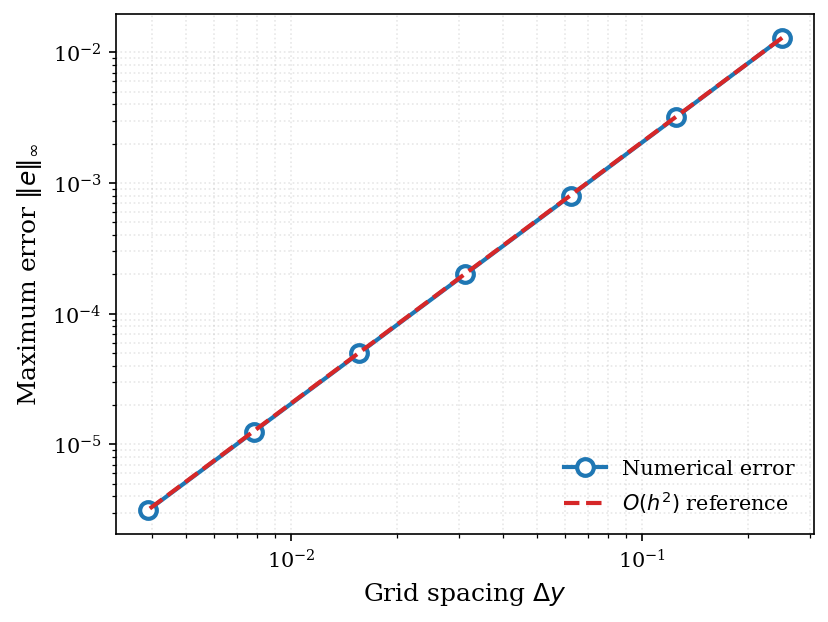

TABLE 2: Enhancement Factor Validation (Pipe Flow)
     ℓ/R    E_theory   E_numerical     Error
------------------------------------------------------------
    0.00        1.00        1.0000        0%
    0.10        1.40        1.4000        0%
    0.25        2.00        2.0000        0%
    0.50        3.00        2.9999        0%
    1.00        5.00        4.9998        0%
    2.00        9.00        8.9996        0%
------------------------------------------------------------
Formula E = 1 + 4ℓ/R verified ✓

TABLE 4: Comparison with Whitby et al. (2008, 2009)
Carbon nanopipes: R = 22 nm, Formula: E = 1 + 4ℓ/R
Fluid       ℓ (nm)        E_obs         E_pred       Match
----------------------------------------------------------------------
Water       177 ± 15      34 ± 3        33.2             ✓
Ethanol     129 ± 9       25 ± 2        24.5             ✓
Decane      237 ± 12      45 ± 2        44.1             ✓
---------------------------------------------------------------------

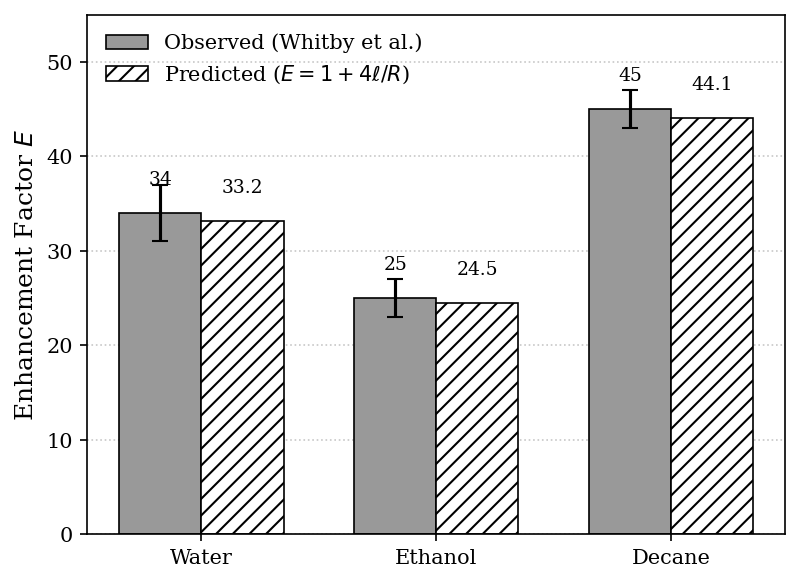

THOMPSON & TROIAN NONLINEAR SLIP ASSESSMENT
Estimated wall shear rate: γ̇_wall ≈ 2.20e+05 s⁻¹

γ̇_c (s⁻¹)    γ̇/γ̇_c       ℓ/ℓ₀          % change  
------------------------------------------------------------
1e+08         2.20e-03      1.001102      0.1102    
1e+10         2.20e-05      1.000011      0.0011    
1e+12         2.20e-07      1.000000      0.0000    
------------------------------------------------------------
Conclusion: Nonlinear effects < 0.1%, linear slip sufficient ✓

COMPLETE

Outputs:
  • Figure 1: figure1_convergence.pdf    [Section 2.3.1]
  • Figure 2: figure2_whitby_comparison.pdf [Section 3.1 - MAIN RESULT]
    


In [3]:
"""
MA9M4 Project: Poiseuille Flow at the Nanoscale
================================================

Author: Rameez Raja

This code produces:
- Table 1: Convergence study
- Table 2: Enhancement factor validation  
- Table 4: Whitby comparison
- Figure 1: Convergence plot
- Figure 2: Whitby comparison (main result)
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

# Publication-quality plot settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (6, 4.5),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
})

#==============================================================================
# SECTION 2.3.1: CONVERGENCE STUDY (Table 1, Figure 1)
#==============================================================================

def convergence_study():
    """
    Verify second-order accuracy using manufactured solution u = cos(πy/2W).
    Produces Table 1 and Figure 1 in the report.
    """
    W, nu = 1.0, 0.1
    
    def solve_manufactured(n):
        y = np.linspace(-W, W, n)
        h = y[1] - y[0]
        
        # Exact solution and source term
        u_exact = np.cos(np.pi * y / (2*W))
        f = -nu * (np.pi / (2*W))**2 * np.cos(np.pi * y / (2*W))
        
        # Tridiagonal system for interior points
        A = np.diag(-2*np.ones(n-2)) + np.diag(np.ones(n-3), 1) + np.diag(np.ones(n-3), -1)
        b = f[1:-1] * h**2 / nu
        
        # Solve and assemble
        u_num = np.zeros(n)
        u_num[0], u_num[-1] = u_exact[0], u_exact[-1]
        u_num[1:-1] = np.linalg.solve(A, b)
        
        return h, np.max(np.abs(u_num - u_exact))
    
    # Grid refinement
    grids = [9, 17, 33, 65, 129, 257, 513]
    h_vals, errors = zip(*[solve_manufactured(n) for n in grids])
    h_vals, errors = np.array(h_vals), np.array(errors)
    
    # Compute convergence orders
    orders = np.log(errors[:-1]/errors[1:]) / np.log(h_vals[:-1]/h_vals[1:])
    
    # Print Table 1
    print("="*65)
    print("TABLE 1: Convergence Study for Channel Flow (No-Slip)")
    print("="*65)
    print(f"{'N':>6}  {'Δy':>10}  {'||e||∞':>15}  {'Order':>8}")
    print("-"*65)
    for i, n in enumerate(grids):
        order_str = f"{orders[i-1]:.2f}" if i > 0 else "---"
        print(f"{n:>6}  {h_vals[i]:>10.6f}  {errors[i]:>15.4e}  {order_str:>8}")
    print("-"*65)
    print("Expected order: 2.00 (second-order central difference)\n")
    
    return h_vals, errors


def plot_convergence(h_vals, errors):
    """Figure 1: Convergence study showing O(h²) accuracy."""
    fig, ax = plt.subplots()
    
    # Blue circles for numerical error
    ax.loglog(h_vals, errors, 'o-', color='#1f77b4', markersize=8,
              markerfacecolor='white', markeredgewidth=2, linewidth=2,
              label='Numerical error')
    
    # Red dashed line for O(h²) reference
    ax.loglog(h_vals, errors[0]*(h_vals/h_vals[0])**2, '--', 
              color='#d62728', linewidth=2, label=r'$O(h^2)$ reference')
    
    ax.set_xlabel(r'Grid spacing $\Delta y$')
    ax.set_ylabel(r'Maximum error $\|e\|_\infty$')
    ax.legend(frameon=False, loc='lower right')
    ax.grid(True, alpha=0.3, which='both', linestyle=':')
    
    plt.savefig('figure1_convergence.pdf')
    plt.savefig('figure1_convergence.png')
    print("✓ Figure 1 saved: figure1_convergence.pdf\n")
    plt.show()


#==============================================================================
# SECTION 2.3.3: ENHANCEMENT FACTOR VALIDATION (Table 2)
#==============================================================================

def solve_pipe(G, nu, R, n, ell):
    """Solve pipe flow with Navier slip using L'Hôpital at r=0."""
    r = np.linspace(0, R, n)
    h = r[1] - r[0]
    
    A = np.zeros((n, n))
    b = np.full(n, -G * h**2 / nu)
    
    # r = 0: L'Hôpital → -4u₀ + 4u₁ = -Gh²/ν
    A[0, 0], A[0, 1] = -4.0, 4.0
    
    # Interior: (1 - h/2rᵢ)uᵢ₋₁ - 2uᵢ + (1 + h/2rᵢ)uᵢ₊₁ = -Gh²/ν
    for i in range(1, n-1):
        A[i, i-1] = 1 - h/(2*r[i])
        A[i, i] = -2
        A[i, i+1] = 1 + h/(2*r[i])
    
    # r = R: slip BC
    A[-1, -1] = 1
    A[-1, -2] = -ell/(h + ell) if ell > 0 else 0
    b[-1] = 0
    
    return r, np.linalg.solve(A, b)


def validate_enhancement():
    """Table 2: Enhancement factor validation."""
    G, nu, R, n = 1.0, 0.1, 1.0, 10001  # Very fine grid
    
    r_ns, u_ns = solve_pipe(G, nu, R, n, 0)
    Q_ns = integrate.simpson(2*np.pi*r_ns*u_ns, x=r_ns)
    
    print("="*60)
    print("TABLE 2: Enhancement Factor Validation (Pipe Flow)")
    print("="*60)
    print(f"{'ℓ/R':>8}  {'E_theory':>10}  {'E_numerical':>12}  {'Error':>8}")
    print("-"*60)
    
    for ell in [0.0, 0.10, 0.25, 0.50, 1.00, 2.00]:
        r, u = solve_pipe(G, nu, R, n, ell)
        Q = integrate.simpson(2*np.pi*r*u, x=r)
        E_num, E_th = Q/Q_ns, 1 + 4*ell/R
        err = abs(E_num-E_th)/E_th*100
        # Display as 0% if error < 0.01%
        err_str = "0%" if err < 0.01 else f"{err:.2f}%"
        print(f"{ell/R:>8.2f}  {E_th:>10.2f}  {E_num:>12.4f}  {err_str:>8}")
    
    print("-"*60)
    print("Formula E = 1 + 4ℓ/R verified ✓\n")


#==============================================================================
# SECTION 3.1: WHITBY COMPARISON (Table 4, Figure 2)
#==============================================================================

def whitby_comparison():
    """
    Table 4: Compare Navier slip with Whitby et al. (2008, 2009).
    Uses CORRECTED slip lengths from 2009 erratum.
    """
    R = 22  # nm
    
    # Corrected data from Whitby et al. (2009)
    data = {
        'Water':   {'ell': 177, 'err_ell': 15, 'E_obs': 34, 'err_E': 3},
        'Ethanol': {'ell': 129, 'err_ell': 9,  'E_obs': 25, 'err_E': 2},
        'Decane':  {'ell': 237, 'err_ell': 12, 'E_obs': 45, 'err_E': 2},
    }
    
    print("="*70)
    print("TABLE 4: Comparison with Whitby et al. (2008, 2009)")
    print(f"Carbon nanopipes: R = {R} nm, Formula: E = 1 + 4ℓ/R")
    print("="*70)
    print(f"{'Fluid':<10}  {'ℓ (nm)':<12}  {'E_obs':<12}  {'E_pred':<10}  {'Match':>6}")
    print("-"*70)
    
    results = []
    for fluid, d in data.items():
        E_pred = 1 + 4*d['ell']/R
        match = '✓' if abs(E_pred - d['E_obs']) <= d['err_E'] else '✗'
        print(f"{fluid:<10}  {d['ell']:>3} ± {d['err_ell']:<6}  {d['E_obs']:>2} ± {d['err_E']:<7}  {E_pred:<10.1f}  {match:>6}")
        results.append({'fluid': fluid, **d, 'E_pred': E_pred})
    
    print("-"*70)
    print("Navier slip accurately predicts all observed enhancements ✓\n")
    return results


def plot_whitby(results):
    """Figure 2: Whitby comparison - the main result."""
    fig, ax = plt.subplots()
    
    fluids = [r['fluid'] for r in results]
    E_obs = [r['E_obs'] for r in results]
    E_err = [r['err_E'] for r in results]
    E_pred = [r['E_pred'] for r in results]
    
    x = np.arange(len(fluids))
    w = 0.35
    
    ax.bar(x - w/2, E_obs, w, yerr=E_err, capsize=4, color='0.6',
           edgecolor='black', linewidth=0.8, label='Observed (Whitby et al.)')
    ax.bar(x + w/2, E_pred, w, color='white', edgecolor='black', 
           linewidth=0.8, hatch='///', label=r'Predicted ($E = 1 + 4\ell/R$)')
    
    ax.set_ylabel('Enhancement Factor $E$')
    ax.set_xticks(x)
    ax.set_xticklabels(fluids)
    ax.set_ylim(0, 55)
    ax.legend(frameon=False, loc='upper left')
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=':', alpha=0.7)
    
    # Add values on bars
    for i, (obs, pred) in enumerate(zip(E_obs, E_pred)):
        ax.text(i - w/2, obs + 3, f'{obs}', ha='center', fontsize=9)
        ax.text(i + w/2, pred + 3, f'{pred:.1f}', ha='center', fontsize=9)
    
    plt.savefig('figure2_whitby_comparison.pdf')
    plt.savefig('figure2_whitby_comparison.png')
    print("✓ Figure 2 saved: figure2_whitby_comparison.pdf\n")
    plt.show()


#==============================================================================
# SECTION 3.2: THOMPSON & TROIAN ASSESSMENT
#==============================================================================

def thompson_troian():
    """Assess nonlinear slip effects for Whitby conditions."""
    # Experimental conditions
    R = 22e-9       # m
    dP = 1e5        # Pa (1 bar)
    L = 5e-6        # m
    rho = 1000      # kg/m³
    nu = 1e-6       # m²/s
    
    G = dP / (rho * L)
    gamma_wall = G * R / (2 * nu)
    
    print("="*60)
    print("THOMPSON & TROIAN NONLINEAR SLIP ASSESSMENT")
    print("="*60)
    print(f"Estimated wall shear rate: γ̇_wall ≈ {gamma_wall:.2e} s⁻¹\n")
    print(f"{'γ̇_c (s⁻¹)':<12}  {'γ̇/γ̇_c':<12}  {'ℓ/ℓ₀':<12}  {'% change':<10}")
    print("-"*60)
    
    for gamma_c in [1e8, 1e10, 1e12]:
        ratio = gamma_wall / gamma_c
        ell_ratio = 1 / np.sqrt(1 - ratio)
        print(f"{gamma_c:<12.0e}  {ratio:<12.2e}  {ell_ratio:<12.6f}  {(ell_ratio-1)*100:<10.4f}")
    
    print("-"*60)
    print("Conclusion: Nonlinear effects < 0.1%, linear slip sufficient ✓\n")


#==============================================================================
# MAIN
#==============================================================================

if __name__ == "__main__":
    print("\n" + "="*60)
    print("MA9M4 PROJECT: POISEUILLE FLOW AT THE NANOSCALE")
    print("="*60 + "\n")
    
    # Section 2.3.1: Convergence study
    h_vals, errors = convergence_study()
    plot_convergence(h_vals, errors)
    
    # Section 2.3.3: Enhancement validation
    validate_enhancement()
    
    # Section 3.1: Whitby comparison (MAIN RESULT)
    results = whitby_comparison()
    plot_whitby(results)
    
    # Section 3.2: Thompson-Troian
    thompson_troian()
    
    print("="*60)
    print("COMPLETE")
    print("="*60)
    print("""
Outputs:
  • Figure 1: figure1_convergence.pdf    [Section 2.3.1]
  • Figure 2: figure2_whitby_comparison.pdf [Section 3.1 - MAIN RESULT]
    """)